In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt

dfs = {}
for folder in os.listdir('runs'):
    log_path = os.path.join('runs', folder, 'results.csv')
    if os.path.exists(log_path):
        dfs[folder] = pd.read_csv(log_path)

In [9]:
trials = {}
for name, df in dfs.items():
    trial_name = name.split('-')[:2]
    trial_name = '-'.join(trial_name)
    if trial_name not in trials:
        trials[trial_name] = []
    trials[trial_name].append(df)

for trial_name, trial_dfs in trials.items():
    print(trial_name, len(trial_dfs))

control-PickCube 3
e2e-PickCube 5
pose-PickCube 5


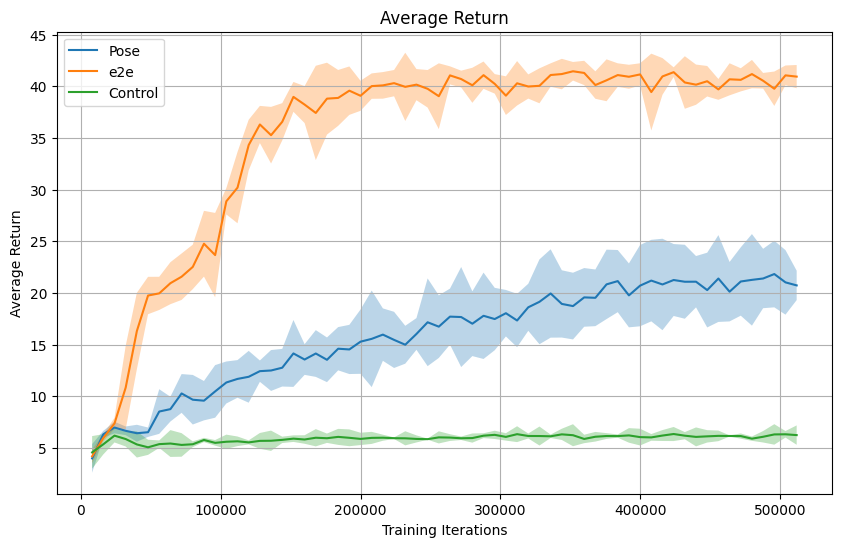

In [10]:
import numpy as np
from scipy import stats

e2e_returns = []
pose_returns = []
control_returns = []
plt.figure(figsize=(10, 6))
for trial_name, trial_dfs in trials.items():
    for df in trial_dfs:
        if 'pose' in trial_name:
            pose_returns.append(df['avg_return'].values)
        elif 'e2e' in trial_name:
            e2e_returns.append(df['avg_return'].values)
        elif 'control' in trial_name:
            control_returns.append(df['avg_return'].values)
if pose_returns:
    pose_return_array = np.stack(pose_returns, axis=1)
    n = pose_return_array.shape[1]
    pose_mean = np.mean(pose_return_array, axis=1)
    pose_sem = stats.sem(pose_return_array, axis=1)
    pose_ci = pose_sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    plt.plot(df['step'], pose_mean, label='Pose')
    plt.fill_between(df['step'], pose_mean - pose_ci, pose_mean + pose_ci, alpha=0.3)
if e2e_returns:
    e2e_return_array = np.stack(e2e_returns, axis=1)
    n = e2e_return_array.shape[1]
    e2e_mean = np.mean(e2e_return_array, axis=1)
    e2e_sem = stats.sem(e2e_return_array, axis=1)
    e2e_ci = e2e_sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    plt.plot(df['step'], e2e_mean, label='e2e')
    plt.fill_between(df['step'], e2e_mean - e2e_ci, e2e_mean + e2e_ci, alpha=0.3)
if control_returns:
    control_return_array = np.stack(control_returns, axis=1)
    n = control_return_array.shape[1]
    control_mean = np.mean(control_return_array, axis=1)
    control_sem = stats.sem(control_return_array, axis=1)
    control_ci = control_sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    plt.plot(df['step'], control_mean, label='Control')
    plt.fill_between(df['step'], control_mean - control_ci, control_mean + control_ci, alpha=0.3)
plt.title(f'Average Return')
plt.xlabel('Training Iterations')
plt.ylabel('Average Return')
plt.legend()
plt.grid()
plt.show()

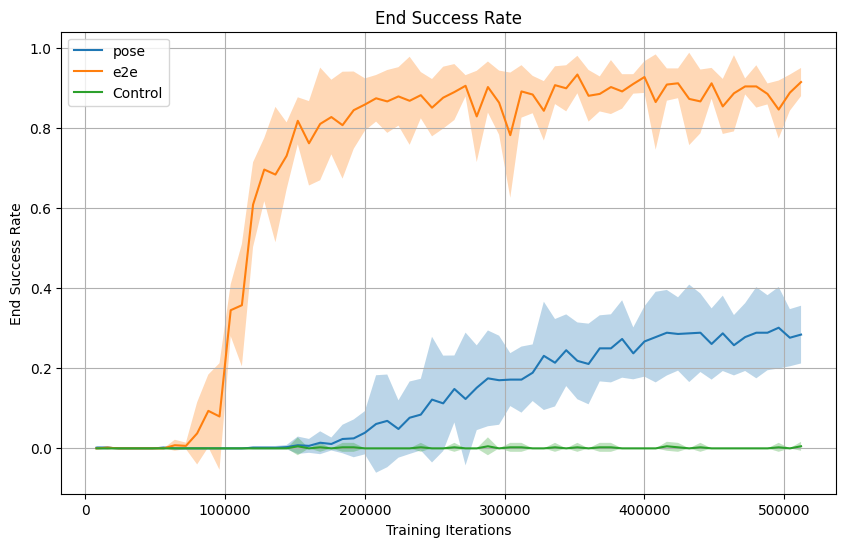

In [11]:
pose_end_success = []
e2e_end_success = []
control_end_success = []
plt.figure(figsize=(10, 6))
for trial_name, trial_dfs in trials.items():
    for df in trial_dfs:
        if 'pose' in trial_name:
            pose_end_success.append(df['success_rate'].values)
        elif 'e2e' in trial_name:
            e2e_end_success.append(df['success_rate'].values)
        elif 'control' in trial_name:
            control_end_success.append(df['success_rate'].values)
if pose_end_success:
    pose_end_success_array = np.stack(pose_end_success, axis=1)
    n = pose_end_success_array.shape[1]
    pose_mean = np.mean(pose_end_success_array, axis=1)
    pose_sem = stats.sem(pose_end_success_array, axis=1)
    pose_ci = pose_sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    plt.plot(df['step'], pose_mean, label='pose')
    plt.fill_between(df['step'], pose_mean - pose_ci, pose_mean + pose_ci, alpha=0.3)
if e2e_end_success:
    e2e_end_success_array = np.stack(e2e_end_success, axis=1)
    n = e2e_end_success_array.shape[1]
    e2e_mean = np.mean(e2e_end_success_array, axis=1)
    e2e_sem = stats.sem(e2e_end_success_array, axis=1)
    e2e_ci = e2e_sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    plt.plot(df['step'], e2e_mean, label='e2e')
    plt.fill_between(df['step'], e2e_mean - e2e_ci, e2e_mean + e2e_ci, alpha=0.3)
if control_end_success:
    control_end_success_array = np.stack(control_end_success, axis=1)
    n = control_end_success_array.shape[1]
    control_mean = np.mean(control_end_success_array, axis=1)
    control_sem = stats.sem(control_end_success_array, axis=1)
    control_ci = control_sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    plt.plot(df['step'], control_mean, label='Control')
    plt.fill_between(df['step'], control_mean - control_ci, control_mean + control_ci, alpha=0.3)
plt.title(f'End Success Rate')
plt.xlabel('Training Iterations')
plt.ylabel('End Success Rate')
plt.legend()
plt.grid()
plt.show()

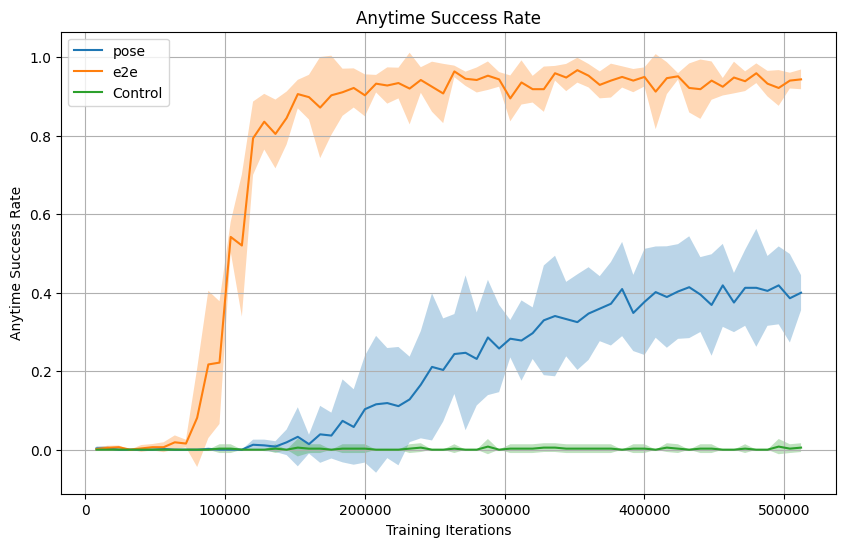

In [12]:
pose_anytime_success = []
e2e_anytime_success = []
control_anytime_success = []
plt.figure(figsize=(10, 6))
for trial_name, trial_dfs in trials.items():
    for df in trial_dfs:
        if 'pose' in trial_name:
            pose_anytime_success.append(df['anytime_success_rate'].values)
        elif 'e2e' in trial_name:
            e2e_anytime_success.append(df['anytime_success_rate'].values)
        elif 'control' in trial_name:
            control_anytime_success.append(df['anytime_success_rate'].values)
if pose_anytime_success:
    pose_anytime_success_array = np.stack(pose_anytime_success, axis=1)
    n = pose_anytime_success_array.shape[1]
    pose_mean = np.mean(pose_anytime_success_array, axis=1)
    pose_sem = stats.sem(pose_anytime_success_array, axis=1)
    pose_ci = pose_sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    plt.plot(df['step'], pose_mean, label='pose')
    plt.fill_between(df['step'], pose_mean - pose_ci, pose_mean + pose_ci, alpha=0.3)
if e2e_anytime_success:
    e2e_anytime_success_array = np.stack(e2e_anytime_success, axis=1)
    n = e2e_anytime_success_array.shape[1]
    e2e_mean = np.mean(e2e_anytime_success_array, axis=1)
    e2e_sem = stats.sem(e2e_anytime_success_array, axis=1)
    e2e_ci = e2e_sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    plt.plot(df['step'], e2e_mean, label='e2e')
    plt.fill_between(df['step'], e2e_mean - e2e_ci, e2e_mean + e2e_ci, alpha=0.3)
if control_anytime_success:
    control_anytime_success_array = np.stack(control_anytime_success, axis=1)
    n = control_anytime_success_array.shape[1]
    control_mean = np.mean(control_anytime_success_array, axis=1)
    control_sem = stats.sem(control_anytime_success_array, axis=1)
    control_ci = control_sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    plt.plot(df['step'], control_mean, label='Control')
    plt.fill_between(df['step'], control_mean - control_ci, control_mean + control_ci, alpha=0.3)
plt.title(f'Anytime Success Rate')
plt.xlabel('Training Iterations')
plt.ylabel('Anytime Success Rate')
plt.legend()
plt.grid()
plt.show()

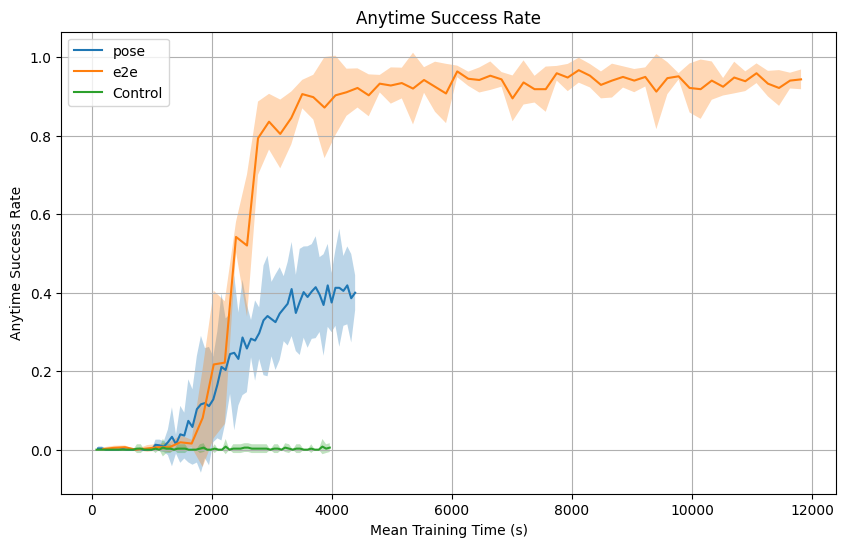

In [13]:
pose_anytime_success = []
pose_wall_times = []
e2e_anytime_success = []
e2e_wall_times = []
control_anytime_success = []
control_wall_times = []
plt.figure(figsize=(10, 6))
for trial_name, trial_dfs in trials.items():
    for df in trial_dfs:
        if 'pose' in trial_name:
            pose_anytime_success.append(df['anytime_success_rate'].values)
            pose_wall_times.append(df['wall_time_s'].values)
        elif 'e2e' in trial_name:
            e2e_anytime_success.append(df['anytime_success_rate'].values)
            e2e_wall_times.append(df['wall_time_s'].values)
        elif 'control' in trial_name:
            control_anytime_success.append(df['anytime_success_rate'].values)
            control_wall_times.append(df['wall_time_s'].values)
if pose_anytime_success:
    pose_anytime_success_array = np.stack(pose_anytime_success, axis=1)
    n = pose_anytime_success_array.shape[1]
    pose_mean = np.mean(pose_anytime_success_array, axis=1)
    pose_sem = stats.sem(pose_anytime_success_array, axis=1)
    pose_ci = pose_sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    pose_wall_times_array = np.stack(pose_wall_times, axis=1)
    pose_wall_times_mean = np.mean(pose_wall_times_array, axis=1)
    plt.plot(pose_wall_times_mean, pose_mean, label='pose')
    plt.fill_between(pose_wall_times_mean, pose_mean - pose_ci, pose_mean + pose_ci, alpha=0.3)
if e2e_anytime_success:
    e2e_anytime_success_array = np.stack(e2e_anytime_success, axis=1)
    n = e2e_anytime_success_array.shape[1]
    e2e_mean = np.mean(e2e_anytime_success_array, axis=1)
    e2e_sem = stats.sem(e2e_anytime_success_array, axis=1)
    e2e_ci = e2e_sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    e2e_wall_times_array = np.stack(e2e_wall_times, axis=1)
    e2e_wall_times_mean = np.mean(e2e_wall_times_array, axis=1)
    plt.plot(e2e_wall_times_mean, e2e_mean, label='e2e')
    plt.fill_between(e2e_wall_times_mean, e2e_mean - e2e_ci, e2e_mean + e2e_ci, alpha=0.3)
if control_anytime_success:
    control_anytime_success_array = np.stack(control_anytime_success, axis=1)
    n = control_anytime_success_array.shape[1]
    control_mean = np.mean(control_anytime_success_array, axis=1)
    control_sem = stats.sem(control_anytime_success_array, axis=1)
    control_ci = control_sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    control_wall_times_array = np.stack(control_wall_times, axis=1)
    control_wall_times_mean = np.mean(control_wall_times_array, axis=1)
    plt.plot(control_wall_times_mean, control_mean, label='Control')
    plt.fill_between(control_wall_times_mean, control_mean - control_ci, control_mean + control_ci, alpha=0.3)
plt.title(f'Anytime Success Rate')
plt.xlabel('Mean Training Time (s)')
plt.ylabel('Anytime Success Rate')
plt.legend()
plt.grid()
plt.show()

In [14]:
pose_action_times = []
e2e_action_times = []
for trial_name, trial_dfs in trials.items():
    for df in trial_dfs:
        if 'pose' in trial_name:
            pose_action_times.append(df['avg_action_time_ms'].values)
        elif 'e2e' in trial_name:
            e2e_action_times.append(df['avg_action_time_ms'].values)
pose_action_times_array = np.concatenate(pose_action_times)
e2e_action_times_array = np.concatenate(e2e_action_times)
pose_mean_action_time = np.mean(pose_action_times_array)
e2e_mean_action_time = np.mean(e2e_action_times_array)
pose_action_time_ci = stats.sem(pose_action_times_array) * stats.t.ppf((1 + 0.95) / 2., len(pose_action_times_array) - 1)
e2e_action_time_ci = stats.sem(e2e_action_times_array) * stats.t.ppf((1 + 0.95) / 2., len(e2e_action_times_array) - 1)
print(f'Single-Cam Pose Mean Action Time: {pose_mean_action_time:.2f} ms ± {pose_action_time_ci:.2f} ms')
print(f'Single-Cam e2e Mean Action Time: {e2e_mean_action_time:.2f} ms ± {e2e_action_time_ci:.2f} ms')

Single-Cam Pose Mean Action Time: 0.48 ms ± 0.01 ms
Single-Cam e2e Mean Action Time: 1.12 ms ± 0.01 ms
